In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import pickle

In [2]:

ds_name = 'markov_32feat_11t5g_less_balanced'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_Markov_imbalanced'
g_resol = 1
model_prefix = 'Joint'

DIR_MODEL_SAVE = os.path.join('sksurv_models/more_g', project, model_prefix)

if os.path.exists(DIR_MODEL_SAVE):
    shutil.rmtree(DIR_MODEL_SAVE)
    os.mkdir(DIR_MODEL_SAVE)
else:
    os.mkdir(DIR_MODEL_SAVE)

In [3]:
from dataset_11t5g_markov import DatasetMarkovSurvSurf

ds_train = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='train', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
ds_val = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='val', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)


In [4]:
df_Xy_train = ds_train._get_df_Xy_trans_obs_more_g()
assert all(
    df_Xy_train.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_train['event_observed'] = df_Xy_train['event_observed'].astype(bool)
df_Xy_train = df_Xy_train.sort_values('subject')

df_Xy_val = ds_val._get_df_Xy_trans_obs()
assert all(
    df_Xy_val.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_val = df_Xy_val.sort_values('subject')
df_Xy_val['event_observed'] = df_Xy_val['event_observed'].astype(bool)

df_Xy_val_grid = ds_val._get_df_Xy_true_prob()
df_Xy_val_grid = df_Xy_val_grid.sort_values(['subject',ds_train.colname_g])
df_Xy_val_grid['event_observed'] = df_Xy_val_grid['event_observed'].astype(bool)


In [5]:
df_Xy_train.head()

,subject,event_observed,duration,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,0,False,8,1.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
1,0,False,8,2.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
2,0,False,8,3.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
3,0,False,8,4.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
4,2,True,2,1.0,1.301429,-0.994802,2.094665,0.359429,0.691002,-1.485720,...,-0.938910,-1.901464,1.095433,-0.333544,-1.441849,-1.416667,-1.629502,0.0,1,1


In [6]:
cols_y = ['event_observed', 'duration']
cols_X = np.r_[[ds_train.colname_g], df_Xy_train.columns[df_Xy_train.columns.str.startswith('feat')]]

In [7]:
cols_y

['event_observed', 'duration']

In [8]:
cols_X

array(['g_max_by_time', 'feat00', 'feat01', 'feat02', 'feat03', 'feat04',
       'feat05', 'feat06', 'feat07', 'feat08', 'feat09', 'feat10',
       'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16',
       'feat17', 'feat18', 'feat19', 'feat20', 'feat21', 'feat22',
       'feat23', 'feat24', 'feat25', 'feat26', 'feat27', 'feat28',
       'feat29', 'feat30', 'feat31'], dtype=object)

In [9]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
def get_non_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(n_jobs=n_jobs, random_state=random_state, min_samples_leaf=3, n_estimators=1000)
        except TypeError:
            return model_class(random_state=random_state, min_samples_leaf=10, n_estimators=50)
    return get_model

def get_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(fit_baseline_model=True, ties='efron')
        except TypeError:
            try:
                return model_class(fit_baseline_model=True)
            except TypeError:
                return model_class()
    return get_model

model_name_to_class = {
    f'{model_prefix}_{GradientBoostingSurvivalAnalysis.__name__}':get_non_cox_model(GradientBoostingSurvivalAnalysis),
    f'{model_prefix}_{RandomSurvivalForest.__name__}':get_non_cox_model(RandomSurvivalForest),
}

In [10]:
df_metrics = []
surv_funcs = dict()
event_to_model = dict()
seeds = [10,20,30,40,50]
for model_name, model_class in model_name_to_class.items():
    for seed in seeds:
        model_id = f'{model_name}_more_g_seed_{seed}'
        model = model_class(n_jobs=-1, random_state=seed)
        y = df_Xy_train[cols_y].to_records(index=False)
        X = df_Xy_train[cols_X]
        model.fit(X, y)

        model_path = os.path.join(DIR_MODEL_SAVE,f'{model_id}.pickle')
        with open(model_path, 'wb') as f:
            # Pickle the 'data' dictionary using the highest protocol available.
            pickle.dump(model, f)

        for g, df_train_sub in df_Xy_train.groupby(ds_train.colname_g):
            if all(df_train_sub['event_observed'] == 0):
                continue
            
            y = df_train_sub[cols_y].to_records(index=False)
            X = df_train_sub[cols_X]
            event_to_model[f'{model_id}_event_{g}'] = model
            record = {
                'model_name':model_name,
                'event':g,
                'seed':seed,
                'c_index_train':model.score(X,y)
            }

            df_val_sub = df_Xy_val.loc[
                df_Xy_val[ds_train.colname_g] == g,:
            ]
            y = df_val_sub[cols_y].to_records(index=False)
            X = df_val_sub[cols_X]
            record['c_index_val'] = model.score(X,y)
            df_metrics.append(record)

            df_val_sub = df_Xy_val_grid.loc[
                df_Xy_val_grid[ds_train.colname_g] == g,:
            ].drop(columns=['duration','event_observed']).drop_duplicates().sort_values('subject')
            X = df_val_sub[cols_X]

            surv_funcs[f'{model_id}_event_{g}'] = model.predict_survival_function(X=X)
        print(f'finished running model {model_name}')
df_metrics = pd.DataFrame(df_metrics)


finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest


In [11]:
df_val_sub

,subject,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,feat06,feat07,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
2,3,3,-1.056169,0.554275,-0.950018,0.857999,-0.532079,1.125759,0.218658,-0.392882,...,0.289559,-0.470209,1.605993,-0.153662,-1.786169,-0.111657,1.537644,0.0,1,NaN
7,7,3,0.761786,-1.646844,0.853926,-0.007960,-0.889475,0.353508,-0.539431,0.591133,...,0.143467,1.434845,1.055364,1.115293,1.801006,-0.194419,-0.842187,0.0,1,NaN
12,15,3,1.905088,0.952670,-0.432973,-0.730569,-1.093725,0.437599,-0.761883,-1.029683,...,-1.071806,1.491680,-0.412008,1.125530,0.298597,0.380416,-0.360827,0.0,1,NaN
17,17,3,-0.851021,0.382710,-2.104251,0.611296,0.334314,1.881421,-0.924426,-0.457373,...,0.820551,0.305156,-1.235898,0.832217,0.382172,-0.732978,0.506060,0.0,1,NaN
22,19,3,0.287647,1.635691,0.114950,0.176676,-0.271338,-0.748332,-0.812047,0.759777,...,0.149182,-0.036294,0.197549,0.526756,-1.869619,0.469936,-0.386902,1.0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2477,1985,3,-0.930535,-0.669600,1.791801,-0.459592,-1.354114,-0.381892,0.153283,2.433270,...,-0.698778,1.069577,2.513857,-0.175994,-0.545026,-0.705365,-1.184941,0.0,1,NaN
2482,1987,3,0.616676,-0.871592,0.610766,-0.067604,0.812099,0.539699,-1.080430,-2.755128,...,0.435016,0.826654,-0.133526,0.689951,0.509071,-0.241583,-1.180800,1.0,1,NaN
2487,1989,3,0.814830,-0.953818,-1.002373,0.312133,-0.711412,-0.600434,0.607461,-0.361851,...,-1.717239,-0.078058,-1.327853,0.200621,-1.224429,-0.420712,0.430444,1.0,1,NaN
2492,1991,3,-0.048159,0.158154,0.991666,-0.793758,-1.262142,-1.117240,0.041638,2.238971,...,-1.395065,-0.478450,-0.731282,0.438083,-0.167460,1.138801,1.433848,0.0,1,NaN


In [12]:
df_metrics.groupby(['model_name','event'])['c_index_val'].describe()

count      mean       std  \
model_name                             event                              
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.679130  0.000000   
                                       2.0      5.0  0.588655  0.000000   
                                       3.0      5.0  0.500000  0.000000   
Joint_RandomSurvivalForest             1.0      5.0  0.728994  0.001383   
                                       2.0      5.0  0.681822  0.008102   
                                       3.0      5.0  0.188462  0.034401   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_GradientBoostingSurvivalAnalysis 1.0    0.679130  0.679130  0.679130   
                                       2.0    0.588655  0.588655  0.588655   
                                       3.0    0.500000  0.500000  0.500000   
Joint_RandomSurvivalForest             1.0    0.727356  0.728248  0.728512   
                                       2.0    0.668877  0.682067  0.683292   
                                       3.0    0.153846  0.163462  0.182692   

                                                   75%       max  
model_name                             event                      
Joint_GradientBoostingSurvivalAnalysis 1.0    0.679130  0.679130  
                                       2.0    0.588655  0.588655  
                                       3.0    0.500000  0.500000  
Joint_RandomSurvivalForest             1.0    0.730237  0.730617  
                                       2.0    0.683581  0.691293  
                                       3.0    0.201923  0.240385

In [13]:
df = df_metrics.copy()
df['val_as_frac_of_train'] = df_metrics['c_index_val']/df_metrics['c_index_train']
df.groupby(['model_name','event'])['val_as_frac_of_train'].describe()

count      mean       std  \
model_name                             event                              
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.892780  0.000000   
                                       2.0      5.0  0.792073  0.000000   
                                       3.0      5.0  0.589904  0.000000   
Joint_RandomSurvivalForest             1.0      5.0  0.754753  0.001705   
                                       2.0      5.0  0.685641  0.008034   
                                       3.0      5.0  0.189005  0.034517   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_GradientBoostingSurvivalAnalysis 1.0    0.892780  0.892780  0.892780   
                                       2.0    0.792073  0.792073  0.792073   
                                       3.0    0.589904  0.589904  0.589904   
Joint_RandomSurvivalForest             1.0    0.752557  0.753638  0.754780   
                                       2.0    0.672828  0.685949  0.687070   
                                       3.0    0.154243  0.163931  0.183217   

                                                   75%       max  
model_name                             event                      
Joint_GradientBoostingSurvivalAnalysis 1.0    0.892780  0.892780  
                                       2.0    0.792073  0.792073  
                                       3.0    0.589904  0.589904  
Joint_RandomSurvivalForest             1.0    0.756111  0.756681  
                                       2.0    0.687271  0.695088  
                                       3.0    0.202561  0.241075

([0, 1],
 [Text(0, 0, 'Joint_GradientBoostingSurvivalAnalysis'),
  Text(1, 0, 'Joint_RandomSurvivalForest')])

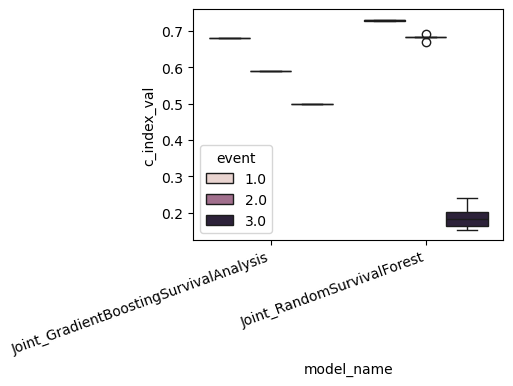

In [14]:
fig, ax = plt.subplots(1,1, figsize=(4, 3))
sns.boxplot(
    data=df_metrics,
    x='model_name',
    y='c_index_val',
    hue='event',
    ax=ax,
)
plt.xticks(rotation=20, ha='right')


In [15]:
n_curves_per_model = [len(i) for i in surv_funcs.values()]

n_curves_per_model = n_curves_per_model[0]

In [16]:
list(surv_funcs.keys())

['Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_40_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_40_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_40_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_50_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_50_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_